# Post Pandemic Regime Shifts in Labor Market: Feature Engineering

## Purpose

## Imports and Configuration

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from regime_shift.config import (
    COLINEAR_PATH,
    FEAT_PATH,
    FIG_ROOT,
    IMPORT_PATH,
    INTERACTION_MODEL_READY_PATH,
    MERGED_PATH,
    MODEL_READY_PATH,
    POST_LABEL,
    PRE_LABEL,
    PRICE_MODEL_READY_PATH,
    PROC_ROOT,
    REGIME_DATES,
    REPORT_ROOT,
    SAVE_DPI,
    SHOCK_LABEL,
    VALID_PATH,
    WAGE_MODEL_READY_PATH,
)
from regime_shift.features import (
    add_base_feature,
    add_change_feature,
    add_feature_pipeline,
    add_interact_feature,
    add_lag_feature,
    add_persistence_feature,
    add_rate_feature,
    add_roll_feature,
    add_state_feature,
    add_target_feature,
    build_model_data,
    choose_candidate,
    choose_core,
    compute_vif,
    feature_diagnostic,
    fill_feature,
    reduce_feature,
    set_regime,
)
from regime_shift.preprocessing import missing_data, set_date

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

project_root = Path.cwd().resolve()
src_root = project_root / "src"

sys.path.insert(0, str(src_root))

FIG_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)
PROC_ROOT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

model_ready_path = MODEL_READY_PATH
wage_ready_path = WAGE_MODEL_READY_PATH
price_ready_path = PRICE_MODEL_READY_PATH
interaction_ready_path = INTERACTION_MODEL_READY_PATH
design_ready_path = PROC_ROOT / "09_model_design_data.csv"

## Load Data

In [2]:
df = pd.read_csv(MERGED_PATH)
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.sort_values("date").reset_index(drop=True)

print(f"Data Shape: {df.shape}")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")

Data Shape: (316, 135)
Date Range: 2000-01-01 to 2026-04-01


## Feature Assessment 

In [3]:
keep_list = [
    "date",
    "job_openings_level",
    "unemployment_level",
    "unemployment_rate",
    "quits_rate",
    "fed_funds",
    "consumer_sentiment",
    "hy_oas",
    "ahe_private",
    "eci_total",
    "cpi_all",
    "cpi_core",
    "pce_price",
    "pce_core",
]

keep_list = [col for col in keep_list if col in df.columns]

In [4]:
overview_data = pd.DataFrame(
    {
        "col": keep_list,
        "missing_count": [int(df[col].isna().sum()) for col in keep_list],
        "missing_pct": [round(100 * df[col].isna().mean(), 2) for col in keep_list],
        "start_date": [df.loc[df[col].notna(), "date"].min() for col in keep_list],
        "end_date": [df.loc[df[col].notna(), "date"].max() for col in keep_list],
    }
)

overview_data.to_csv(REPORT_ROOT / "04_feature_input_overview.csv", index=False)
overview_data

,col,missing_count,missing_pct,start_date,end_date
0,date,0,0.0000,2000-01-01,2026-04-01
1,job_openings_level,13,4.1100,2000-12-01,2026-02-01
2,unemployment_level,2,0.6300,2000-01-01,2026-03-01
3,unemployment_rate,2,0.6300,2000-01-01,2026-03-01
4,quits_rate,13,4.1100,2000-12-01,2026-02-01
5,fed_funds,1,0.3200,2000-01-01,2026-03-01
6,consumer_sentiment,2,0.6300,2000-01-01,2026-02-01
7,hy_oas,0,0.0000,2000-01-01,2026-04-01
8,ahe_private,75,23.7300,2006-03-01,2026-03-01
9,eci_total,18,5.7000,2001-01-01,2025-10-01


## Regime Definition

In [5]:
shock_start = pd.Timestamp(REGIME_DATES["shock_start"])
shock_end = pd.Timestamp(REGIME_DATES["shock_end"])
post_start = pd.Timestamp(REGIME_DATES["post_start"])
post_end = pd.Timestamp(REGIME_DATES["post_end"])
pre_end = pd.Timestamp(REGIME_DATES["pre_end"])

In [6]:
def safe_log(series):
    return np.log(series.where(series > 0))

def set_phase(data):
    out = data.copy()

    out["regime"] = "Pre-2020"
    out.loc[out["date"] >= shock_start, "regime"] = "Pandemic Shock (2020-2021H1)"
    out.loc[out["date"] >= post_start, "regime"] = "Post-Pandemic (2021-06+)"

    out["pre_regime"] = (out["date"] <= pre_end).astype(int)
    out["shock_regime"] = ((out["date"] >= shock_start) & (out["date"] <= shock_end)).astype(int)
    out["post_regime"] = (out["date"] >= post_start).astype(int)

    out["split_role"] = "pre_train"
    out.loc[out["shock_regime"] == 1, "split_role"] = "shock_eval"
    out.loc[out["post_regime"] == 1, "split_role"] = "post_eval"

    return out

def annual_rate(series, horizon):
    return 100 * (12 / horizon) * (safe_log(series) - safe_log(series).shift(horizon))

def add_change(data, col_list, step_list):
    out = data.copy()

    for col in col_list:
        if col not in out.columns:
            continue
        for step in step_list:
            out[f"{col}_chg_{step}"] = out[col].diff(step)

    return out

def add_window(data, col_list, win_list):
    out = data.copy()

    for col in col_list:
        if col not in out.columns:
            continue
        for win in win_list:
            out[f"{col}_mean_{win}"] = out[col].rolling(win).mean()
            out[f"{col}_std_{win}"] = out[col].rolling(win).std()

    return out

def add_sample(data, target_col, name):
    out = data.copy()

    out[f"{name}_valid"] = out[target_col].notna().astype(int)
    out[f"{name}_train"] = ((out["pre_regime"] == 1) & out[target_col].notna()).astype(int)
    out[f"{name}_shock"] = ((out["shock_regime"] == 1) & out[target_col].notna()).astype(int)
    out[f"{name}_post"] = ((out["post_regime"] == 1) & out[target_col].notna()).astype(int)

    return out

def sample_view(data, target_col, name):
    use = data.loc[data[target_col].notna(), ["date", "regime"]].copy()

    if len(use) == 0:
        return pd.DataFrame()

    return pd.DataFrame(
        [
            {
                "name": name,
                "target_col": target_col,
                "start_date": use["date"].min(),
                "end_date": use["date"].max(),
                "obs": len(use),
                "pre_obs": int((use["date"] <= pre_end).sum()),
                "shock_obs": int(((use["date"] >= shock_start) & (use["date"] <= shock_end)).sum()),
                "post_obs": int((use["date"] >= post_start).sum()),
            }
        ]
    )

def dedupe_col(data):
    out = data.copy()
    out = out.loc[:, ~out.columns.duplicated()].copy()
    return out

def build_design(data, id_cols, feature_cols, target_col, design_name):
    use_cols = id_cols + feature_cols + [target_col]
    use_cols = [col for col in use_cols if col in data.columns]
    out = data[use_cols].copy()
    out["design_name"] = design_name
    out["target_name"] = target_col
    out["target_valid"] = out[target_col].notna().astype(int)
    return out

def build_audit(name, value, passed):
    return {"audit_name": name, "audit_value": value, "audit_pass": bool(passed)}

df = set_phase(df)

## Core Feature Construction

In [7]:
df = add_base_feature(df)

if {"job_openings_level", "unemployment_level"}.issubset(df.columns):
    df["jolts_ratio"] = df["job_openings_level"] / df["unemployment_level"]
    df["log_jolts_ratio"] = safe_log(df["jolts_ratio"])

if "ahe_private" in df.columns:
    df["log_ahe_private"] = safe_log(df["ahe_private"])

if "cpi_all" in df.columns:
    df["log_cpi_all"] = safe_log(df["cpi_all"])

if "pce_price" in df.columns:
    df["log_pce_price"] = safe_log(df["pce_price"])

if "cpi_core" in df.columns:
    df["log_cpi_core"] = safe_log(df["cpi_core"])

if "pce_core" in df.columns:
    df["log_pce_core"] = safe_log(df["pce_core"])

In [8]:
drop_cols = []
drop_cols += [col for col in df.columns if col.endswith("_scale")]
drop_cols += [col for col in df.columns if col.endswith(".1")]
drop_cols += [col for col in df.columns if "_x_post_regime" in col]
drop_cols += [col for col in df.columns if col.startswith("price_target_")]
drop_cols += [col for col in df.columns if col.startswith("wage_target_0")]
drop_cols += [col for col in df.columns if col.startswith("price_target_0")]
drop_cols += [col for col in df.columns if col.startswith("cpi_target_0")]
drop_cols += [col for col in df.columns if col.startswith("pce_target_0")]
drop_cols += [col for col in df.columns if col.startswith("wage_target")]
drop_cols += [col for col in df.columns if col.startswith("cpi_target")]
drop_cols += [col for col in df.columns if col.startswith("pce_target")]
drop_cols = sorted(list(set([col for col in drop_cols if col in df.columns])))

if len(drop_cols) > 0:
    df = df.drop(columns=drop_cols, errors="ignore")

In [9]:
for horizon in [3, 6, 12]:
    if "ahe_private" in df.columns:
        df[f"ahe_{horizon}m_pct"] = annual_rate(df["ahe_private"], horizon)
        df[f"wage_target_{horizon}"] = df[f"ahe_{horizon}m_pct"].shift(-horizon)

    if "cpi_all" in df.columns:
        df[f"cpi_{horizon}m_pct"] = annual_rate(df["cpi_all"], horizon)
        df[f"cpi_target_{horizon}"] = df[f"cpi_{horizon}m_pct"].shift(-horizon)

    if "pce_price" in df.columns:
        df[f"pce_{horizon}m_pct"] = annual_rate(df["pce_price"], horizon)
        df[f"pce_target_{horizon}"] = df[f"pce_{horizon}m_pct"].shift(-horizon)

    if "cpi_core" in df.columns:
        df[f"cpi_core_{horizon}m_pct"] = annual_rate(df["cpi_core"], horizon)

    if "pce_core" in df.columns:
        df[f"pce_core_{horizon}m_pct"] = annual_rate(df["pce_core"], horizon)

pre_data = df[df["pre_regime"] == 1].copy()

In [10]:
if "cpi_12m_pct" in df.columns:
    high_cut = pre_data["cpi_12m_pct"].dropna().quantile(0.75)
    df["high_inflation"] = (df["cpi_12m_pct"] >= high_cut).astype(int)

if "unemployment_rate" in df.columns:
    labor_cut = pre_data["unemployment_rate"].dropna().quantile(0.25)
    df["tight_labor"] = (df["unemployment_rate"] <= labor_cut).astype(int)

if "hy_oas" in df.columns:
    stress_cut = pre_data["hy_oas"].dropna().quantile(0.75)
    df["credit_stress"] = (df["hy_oas"] >= stress_cut).astype(int)

In [11]:
lag_cols = [
    "log_jolts_ratio",
    "jolts_ratio",
    "unemployment_rate",
    "quits_rate",
    "fed_funds",
    "consumer_sentiment",
    "hy_oas",
]

lag_cols = [col for col in lag_cols if col in df.columns]

df = add_lag_feature(df, lag_cols, lag_list=[1, 3, 6, 12])

In [12]:
for horizon in [3, 6, 12]:
    if f"ahe_{horizon}m_pct" in df.columns:
        df[f"ahe_{horizon}m_pct_lag_1"] = df[f"ahe_{horizon}m_pct"].shift(1)
        df[f"ahe_{horizon}m_pct_lag_{horizon}"] = df[f"ahe_{horizon}m_pct"].shift(horizon)

    if f"cpi_{horizon}m_pct" in df.columns:
        df[f"cpi_{horizon}m_pct_lag_1"] = df[f"cpi_{horizon}m_pct"].shift(1)
        df[f"cpi_{horizon}m_pct_lag_{horizon}"] = df[f"cpi_{horizon}m_pct"].shift(horizon)

    if f"pce_{horizon}m_pct" in df.columns:
        df[f"pce_{horizon}m_pct_lag_1"] = df[f"pce_{horizon}m_pct"].shift(1)
        df[f"pce_{horizon}m_pct_lag_{horizon}"] = df[f"pce_{horizon}m_pct"].shift(horizon)


In [13]:
for horizon in [3, 6, 12]:
    if f"ahe_{horizon}m_pct_lag_1" in df.columns:
        df[f"wage_persist_{horizon}"] = df[f"ahe_{horizon}m_pct_lag_1"]

    if f"cpi_{horizon}m_pct_lag_1" in df.columns:
        df[f"cpi_persist_{horizon}"] = df[f"cpi_{horizon}m_pct_lag_1"]

    if f"pce_{horizon}m_pct_lag_1" in df.columns:
        df[f"pce_persist_{horizon}"] = df[f"pce_{horizon}m_pct_lag_1"]

In [14]:
change_cols = [
    "log_jolts_ratio",
    "jolts_ratio",
    "unemployment_rate",
    "quits_rate",
    "fed_funds",
    "consumer_sentiment",
    "hy_oas",
]

change_cols = [col for col in change_cols if col in df.columns]
df = add_change(df, change_cols, [1, 3, 6, 12])

In [15]:
window_cols = [
    "log_jolts_ratio",
    "jolts_ratio",
    "unemployment_rate",
    "quits_rate",
    "ahe_3m_pct",
    "ahe_6m_pct",
    "ahe_12m_pct",
    "cpi_3m_pct",
    "cpi_6m_pct",
    "cpi_12m_pct",
    "pce_3m_pct",
    "pce_6m_pct",
    "pce_12m_pct",
]

window_cols = [col for col in window_cols if col in df.columns]
df = add_window(df, window_cols, [3, 6, 12])

In [16]:
interaction_cols = []
base_interaction_cols = [
    "log_jolts_ratio",
    "jolts_ratio",
    "quits_rate",
    "unemployment_rate",
]

base_interaction_cols = [col for col in base_interaction_cols if col in df.columns]

for col in base_interaction_cols:
    if "high_inflation" in df.columns:
        name = f"{col}_x_high_inflation"
        df[name] = df[col] * df["high_inflation"]
        interaction_cols.append(name)

    if "tight_labor" in df.columns:
        name = f"{col}_x_tight_labor"
        df[name] = df[col] * df["tight_labor"]
        interaction_cols.append(name)

    if "credit_stress" in df.columns:
        name = f"{col}_x_credit_stress"
        df[name] = df[col] * df["credit_stress"]
        interaction_cols.append(name)

In [17]:
df = dedupe_col(df)

target_cols = [col for col in df.columns if col.startswith("wage_target_") or col.startswith("cpi_target_") or col.startswith("pce_target_")]

num_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in target_cols]
df[num_cols] = df[num_cols].ffill(limit=3)

In [18]:
tightness_cols = [
    "jolts_ratio",
    "log_jolts_ratio",
    "jolts_ratio_lag_1",
    "jolts_ratio_lag_3",
    "jolts_ratio_lag_6",
    "log_jolts_ratio_lag_1",
    "log_jolts_ratio_lag_3",
    "log_jolts_ratio_lag_6",
    "log_jolts_ratio_chg_1",
    "log_jolts_ratio_chg_3",
    "log_jolts_ratio_chg_6",
    "log_jolts_ratio_std_3",
    "log_jolts_ratio_std_6",
    "log_jolts_ratio_std_12",
]

In [19]:
labor_cols = [
    "unemployment_rate",
    "unemployment_rate_lag_1",
    "unemployment_rate_lag_3",
    "unemployment_rate_lag_6",
    "unemployment_rate_chg_1",
    "unemployment_rate_chg_3",
    "unemployment_rate_chg_6",
    "quits_rate",
    "quits_rate_lag_1",
    "quits_rate_lag_3",
    "quits_rate_lag_6",
    "quits_rate_chg_1",
    "quits_rate_chg_3",
    "quits_rate_chg_6",
]

In [20]:
macro_cols = [
    "fed_funds",
    "fed_funds_lag_1",
    "fed_funds_lag_3",
    "fed_funds_chg_1",
    "fed_funds_chg_3",
    "consumer_sentiment",
    "consumer_sentiment_lag_1",
    "consumer_sentiment_lag_3",
    "consumer_sentiment_chg_1",
    "consumer_sentiment_chg_3",
    "hy_oas",
    "hy_oas_lag_1",
    "hy_oas_lag_3",
    "hy_oas_chg_1",
    "hy_oas_chg_3",
]

In [21]:
state_cols = [
    "high_inflation",
    "tight_labor",
    "credit_stress",
]

In [22]:
tightness_cols = [col for col in tightness_cols if col in df.columns]
labor_cols = [col for col in labor_cols if col in df.columns]
macro_cols = [col for col in macro_cols if col in df.columns]
state_cols = [col for col in state_cols if col in df.columns]
interaction_cols = [col for col in interaction_cols if col in df.columns]

In [23]:
for horizon in [3, 6, 12]:
    if f"wage_target_{horizon}" in df.columns:
        df = add_sample(df, f"wage_target_{horizon}", f"wage_{horizon}")

    if f"cpi_target_{horizon}" in df.columns:
        df = add_sample(df, f"cpi_target_{horizon}", f"cpi_{horizon}")

    if f"pce_target_{horizon}" in df.columns:
        df = add_sample(df, f"pce_target_{horizon}", f"pce_{horizon}")

## Sample 

In [24]:
sample_rows = []

for horizon in [3, 6, 12]:
    if f"wage_target_{horizon}" in df.columns:
        sample_rows.append(sample_view(df, f"wage_target_{horizon}", f"wage_{horizon}"))

    if f"cpi_target_{horizon}" in df.columns:
        sample_rows.append(sample_view(df, f"cpi_target_{horizon}", f"cpi_{horizon}"))

    if f"pce_target_{horizon}" in df.columns:
        sample_rows.append(sample_view(df, f"pce_target_{horizon}", f"pce_{horizon}"))

sample_data = pd.concat(sample_rows, axis=0).reset_index(drop=True)
sample_data.to_csv(REPORT_ROOT / "04_target_samples.csv", index=False)
sample_data

,name,target_col,start_date,end_date,obs,pre_obs,shock_obs,post_obs
0,wage_3,wage_target_3,2006-03-01,2025-12-01,238,166,17,55
1,cpi_3,cpi_target_3,2000-01-01,2025-12-01,310,240,17,53
2,pce_3,pce_target_3,2000-01-01,2025-11-01,311,240,17,54
3,wage_6,wage_target_6,2006-03-01,2025-09-01,235,166,17,52
4,cpi_6,cpi_target_6,2000-01-01,2025-09-01,308,240,17,51
5,pce_6,pce_target_6,2000-01-01,2025-08-01,308,240,17,51
6,wage_12,wage_target_12,2006-03-01,2025-03-01,229,166,17,46
7,cpi_12,cpi_target_12,2000-01-01,2025-03-01,302,240,17,45
8,pce_12,pce_target_12,2000-01-01,2025-02-01,302,240,17,45


In [25]:
group_data = pd.DataFrame(
    {
        "group": ["tightness", "labor", "macro", "state", "interaction"],
        "count": [len(tightness_cols), len(labor_cols), len(macro_cols), len(state_cols), len(interaction_cols)],
        "col_list": [
            ", ".join(tightness_cols),
            ", ".join(labor_cols),
            ", ".join(macro_cols),
            ", ".join(state_cols),
            ", ".join(interaction_cols),
        ],
    }
)

group_data.to_csv(REPORT_ROOT / "04_feature_groups.csv", index=False)
group_data

,group,count,col_list
0,tightness,14,"jolts_ratio, log_jolts_ratio, jolts_ratio_lag_..."
1,labor,14,"unemployment_rate, unemployment_rate_lag_1, un..."
2,macro,15,"fed_funds, fed_funds_lag_1, fed_funds_lag_3, f..."
3,state,3,"high_inflation, tight_labor, credit_stress"
4,interaction,12,"log_jolts_ratio_x_high_inflation, log_jolts_ra..."


In [26]:
review_cols = sorted(list(dict.fromkeys(tightness_cols + labor_cols + macro_cols + state_cols)))
review_data = df[review_cols].copy()

In [27]:
pair_rows = []
if len(review_cols) > 1:
    matrix_data = review_data.dropna().corr().abs()
    for left_idx, left_col in enumerate(matrix_data.columns):
        for right_idx, right_col in enumerate(matrix_data.columns):
            if right_idx <= left_idx:
                continue
            value = matrix_data.iloc[left_idx, right_idx]
            if pd.notna(value) and value >= 0.85:
                pair_rows.append({"left_col": left_col, "right_col": right_col, "correlation_value": float(value)})

pair_table = pd.DataFrame(pair_rows).sort_values("correlation_value", ascending=False).reset_index(drop=True) if len(pair_rows) > 0 else pd.DataFrame(columns=["left_col", "right_col", "correlation_value"])
pair_table.to_csv(REPORT_ROOT / "04_high_correlation.csv", index=False)

In [28]:
vif_table = compute_vif(df, review_cols)
vif_table.to_csv(REPORT_ROOT / "04_vif_data.csv", index=False)

print(pair_table.head(20))
print(vif_table.head(20))

                 left_col                 right_col  correlation_value
0               fed_funds           fed_funds_lag_1             0.9958
1             jolts_ratio         jolts_ratio_lag_1             0.9887
2         log_jolts_ratio     log_jolts_ratio_lag_1             0.9853
3         fed_funds_lag_1           fed_funds_lag_3             0.9849
4       jolts_ratio_lag_1         jolts_ratio_lag_3             0.9750
5               fed_funds           fed_funds_lag_3             0.9705
6   log_jolts_ratio_lag_1     log_jolts_ratio_lag_3             0.9687
7                  hy_oas              hy_oas_lag_1             0.9631
8              quits_rate          quits_rate_lag_1             0.9604
9             jolts_ratio         jolts_ratio_lag_3             0.9598
10      jolts_ratio_lag_3         jolts_ratio_lag_6             0.9592
11        log_jolts_ratio     log_jolts_ratio_lag_3             0.9532
12  log_jolts_ratio_lag_3     log_jolts_ratio_lag_6             0.9522
13    

In [29]:
feature_rows = []
for col in review_cols:
    row = {
        "feature": col,
        "missing_count": int(df[col].isna().sum()),
        "missing_pct": round(100 * df[col].isna().mean(), 2),
        "mean_all": df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else np.nan,
        "std_all": df[col].std() if pd.api.types.is_numeric_dtype(df[col]) else np.nan,
    }

    for label in ["Pre-2020", "Pandemic Shock (2020-2021H1)", "Post-Pandemic (2021-06+)"]:
        use = df.loc[df["regime"] == label, col]
        row[f"mean_{label}"] = use.mean() if pd.api.types.is_numeric_dtype(use) else np.nan
        row[f"std_{label}"] = use.std() if pd.api.types.is_numeric_dtype(use) else np.nan

    feature_rows.append(row)

feature_review = pd.DataFrame(feature_rows).sort_values(["missing_pct", "feature"]).reset_index(drop=True)
feature_review.to_csv(REPORT_ROOT / "04_feature_review.csv", index=False)
feature_review.head(20)

,feature,missing_count,missing_pct,mean_all,std_all,mean_Pre-2020,std_Pre-2020,mean_Pandemic Shock (2020-2021H1),std_Pandemic Shock (2020-2021H1),mean_Post-Pandemic (2021-06+),std_Post-Pandemic (2021-06+)
0,consumer_sentiment,0,0.0000,81.5734,14.1152,85.7821,12.2573,81.7882,8.6917,64.3915,8.2770
1,credit_stress,0,0.0000,0.1994,0.4002,0.2500,0.4339,0.1765,0.3930,0.0000,0.0000
2,fed_funds,0,0.0000,2.0284,2.0272,1.7842,1.9171,0.2871,0.5006,3.5239,1.9217
3,high_inflation,0,0.0000,0.3228,0.4683,0.2375,0.4264,0.1176,0.3321,0.7288,0.4484
4,hy_oas,0,0.0000,5.3324,2.5963,5.7880,2.7614,4.9430,1.5946,3.5915,0.7077
5,tight_labor,0,0.0000,0.3671,0.4828,0.2500,0.4339,0.1765,0.3930,0.8983,0.3048
6,unemployment_rate,0,0.0000,5.6237,1.9360,5.8812,1.8095,7.5176,3.1463,4.0305,0.4732
7,consumer_sentiment_chg_1,1,0.3200,-0.1746,4.2904,-0.0531,4.0693,-0.9647,6.5610,-0.4390,4.4176
8,consumer_sentiment_lag_1,1,0.3200,81.6527,14.0670,85.7255,12.2516,82.7529,9.6771,64.8373,8.5537
9,fed_funds_chg_1,1,0.3200,-0.0057,0.1816,-0.0163,0.1657,-0.0876,0.2618,0.0607,0.2004


In [30]:
id_cols = [
    "date",
    "regime",
    "split_role",
    "pre_regime",
    "shock_regime",
    "post_regime",
]

sample_cols = [col for col in df.columns if col.endswith("_valid") or col.endswith("_train") or col.endswith("_shock") or col.endswith("_post")]
sample_cols = [col for col in sample_cols if col in df.columns]

In [31]:
wage_map = {}
price_map = {}

for horizon in [3, 6, 12]:
    wage_persist_cols = [f"wage_persist_{horizon}"]
    wage_persist_cols = [col for col in wage_persist_cols if col in df.columns]

    cpi_persist_cols = [f"cpi_persist_{horizon}"]
    cpi_persist_cols = [col for col in cpi_persist_cols if col in df.columns]

    pce_persist_cols = [f"pce_persist_{horizon}"]
    pce_persist_cols = [col for col in pce_persist_cols if col in df.columns]

    wage_map[horizon] = {
        "tightness_cols": tightness_cols.copy(),
        "labor_cols": labor_cols.copy(),
        "macro_cols": macro_cols.copy(),
        "state_cols": state_cols.copy(),
        "persistence_cols": wage_persist_cols,
        "full_cols": sorted(list(dict.fromkeys(tightness_cols + labor_cols + macro_cols + state_cols + wage_persist_cols))),
        "interaction_cols": interaction_cols.copy(),
    }

    price_map[f"cpi_{horizon}"] = {
        "tightness_cols": tightness_cols.copy(),
        "labor_cols": labor_cols.copy(),
        "macro_cols": macro_cols.copy(),
        "state_cols": state_cols.copy(),
        "persistence_cols": cpi_persist_cols,
        "full_cols": sorted(list(dict.fromkeys(tightness_cols + labor_cols + macro_cols + state_cols + cpi_persist_cols))),
        "interaction_cols": interaction_cols.copy(),
    }

    price_map[f"pce_{horizon}"] = {
        "tightness_cols": tightness_cols.copy(),
        "labor_cols": labor_cols.copy(),
        "macro_cols": macro_cols.copy(),
        "state_cols": state_cols.copy(),
        "persistence_cols": pce_persist_cols,
        "full_cols": sorted(list(dict.fromkeys(tightness_cols + labor_cols + macro_cols + state_cols + pce_persist_cols))),
        "interaction_cols": interaction_cols.copy(),
    }

In [32]:
main_feature_cols = sorted(list(dict.fromkeys(tightness_cols + labor_cols + macro_cols + state_cols)))
default_feature_cols = sorted(list(dict.fromkeys(id_cols + sample_cols + main_feature_cols + target_cols)))
default_feature_cols = [col for col in default_feature_cols if col in df.columns]

interaction_feature_cols = sorted(list(dict.fromkeys(id_cols + sample_cols + interaction_cols + target_cols)))
interaction_feature_cols = [col for col in interaction_feature_cols if col in df.columns]

final_data = df[default_feature_cols].copy()
interaction_data = df[interaction_feature_cols].copy()

In [33]:
wage_parts = []
price_parts = []
design_rows = []

for horizon in [3, 6, 12]:
    wage_target = f"wage_target_{horizon}"
    cpi_target = f"cpi_target_{horizon}"
    pce_target = f"pce_target_{horizon}"

    if wage_target in final_data.columns:
        wage_parts.append(build_design(final_data, id_cols + sample_cols, wage_map[horizon]["full_cols"], wage_target, f"wage_{horizon}_full"))
        design_rows.append(
            {
                "design_name": f"wage_{horizon}",
                "experiment_name": "wage",
                "target_col": wage_target,
                "horizon": horizon,
                "tightness_cols": "|".join(wage_map[horizon]["tightness_cols"]),
                "labor_cols": "|".join(wage_map[horizon]["labor_cols"]),
                "macro_cols": "|".join(wage_map[horizon]["macro_cols"]),
                "state_cols": "|".join(wage_map[horizon]["state_cols"]),
                "persistence_cols": "|".join(wage_map[horizon]["persistence_cols"]),
                "full_cols": "|".join(wage_map[horizon]["full_cols"]),
                "interaction_cols": "|".join(wage_map[horizon]["interaction_cols"]),
            }
        )

    if cpi_target in final_data.columns:
        price_parts.append(build_design(final_data, id_cols + sample_cols, price_map[f"cpi_{horizon}"]["full_cols"], cpi_target, f"cpi_{horizon}_full"))
        design_rows.append(
            {
                "design_name": f"cpi_{horizon}",
                "experiment_name": "price",
                "target_col": cpi_target,
                "horizon": horizon,
                "tightness_cols": "|".join(price_map[f"cpi_{horizon}"]["tightness_cols"]),
                "labor_cols": "|".join(price_map[f"cpi_{horizon}"]["labor_cols"]),
                "macro_cols": "|".join(price_map[f"cpi_{horizon}"]["macro_cols"]),
                "state_cols": "|".join(price_map[f"cpi_{horizon}"]["state_cols"]),
                "persistence_cols": "|".join(price_map[f"cpi_{horizon}"]["persistence_cols"]),
                "full_cols": "|".join(price_map[f"cpi_{horizon}"]["full_cols"]),
                "interaction_cols": "|".join(price_map[f"cpi_{horizon}"]["interaction_cols"]),
            }
        )

    if pce_target in final_data.columns:
        price_parts.append(build_design(final_data, id_cols + sample_cols, price_map[f"pce_{horizon}"]["full_cols"], pce_target, f"pce_{horizon}_full"))
        design_rows.append(
            {
                "design_name": f"pce_{horizon}",
                "experiment_name": "price",
                "target_col": pce_target,
                "horizon": horizon,
                "tightness_cols": "|".join(price_map[f"pce_{horizon}"]["tightness_cols"]),
                "labor_cols": "|".join(price_map[f"pce_{horizon}"]["labor_cols"]),
                "macro_cols": "|".join(price_map[f"pce_{horizon}"]["macro_cols"]),
                "state_cols": "|".join(price_map[f"pce_{horizon}"]["state_cols"]),
                "persistence_cols": "|".join(price_map[f"pce_{horizon}"]["persistence_cols"]),
                "full_cols": "|".join(price_map[f"pce_{horizon}"]["full_cols"]),
                "interaction_cols": "|".join(price_map[f"pce_{horizon}"]["interaction_cols"]),
            }
        )

In [34]:
wage_data = pd.concat(wage_parts, axis=0).reset_index(drop=True)
price_data = pd.concat(price_parts, axis=0).reset_index(drop=True)
design_data = pd.DataFrame(design_rows)

wage_data.to_csv(wage_ready_path, index=False)
price_data.to_csv(price_ready_path, index=False)
interaction_data.to_csv(interaction_ready_path, index=False)
design_data.to_csv(design_ready_path, index=False)

final_data.to_csv(model_ready_path, index=False)

In [35]:
target_zero_cols = [col for col in final_data.columns if col.endswith("_0") or "_target_0" in col]

scaled_cols = [col for col in final_data.columns if col.endswith("_scale")]

duplicate_count = int(final_data.columns.duplicated().sum())

leak_name_cols = [col for col in main_feature_cols if "target_" in col.lower() or "forward_" in col.lower() or "future_" in col.lower() or "lead_" in col.lower()]

post_interaction_cols = [col for col in main_feature_cols if "_x_post_regime" in col]

regime_need = ["regime", "pre_regime", "shock_regime", "post_regime", "split_role"]
regime_missing = [col for col in regime_need if col not in final_data.columns]

rolling_center_cols = [col for col in final_data.columns if "_mean_" in col or "_std_" in col]
rolling_center_flag = False

In [36]:
audit_rows = []
audit_rows.append(build_audit("no_horizon_zero_targets", len(target_zero_cols), len(target_zero_cols) == 0))
audit_rows.append(build_audit("no_scaled_cols_in_export", len(scaled_cols), len(scaled_cols) == 0))
audit_rows.append(build_audit("no_duplicate_cols_in_export", duplicate_count, duplicate_count == 0))
audit_rows.append(build_audit("no_leak_name_cols_in_default_features", len(leak_name_cols), len(leak_name_cols) == 0))
audit_rows.append(build_audit("no_post_regime_interaction_in_default_features", len(post_interaction_cols), len(post_interaction_cols) == 0))
audit_rows.append(build_audit("regime_cols_present", len(regime_missing), len(regime_missing) == 0))
audit_rows.append(build_audit("rolling_features_are_trailing", int(rolling_center_flag), rolling_center_flag is False))
audit_rows.append(build_audit("wage_file_saved", int(wage_ready_path.exists()), wage_ready_path.exists()))
audit_rows.append(build_audit("price_file_saved", int(price_ready_path.exists()), price_ready_path.exists()))
audit_rows.append(build_audit("model_file_saved", int(model_ready_path.exists()), model_ready_path.exists()))

audit_table = pd.DataFrame(audit_rows)
audit_table.to_csv(REPORT_ROOT / "04_audit_table.csv", index=False)
audit_table

,audit_name,audit_value,audit_pass
0,no_horizon_zero_targets,0,True
1,no_scaled_cols_in_export,0,True
2,no_duplicate_cols_in_export,0,True
3,no_leak_name_cols_in_default_features,0,True
4,no_post_regime_interaction_in_default_features,0,True
5,regime_cols_present,0,True
6,rolling_features_are_trailing,0,True
7,wage_file_saved,1,True
8,price_file_saved,1,True
9,model_file_saved,1,True


In [37]:
coverage_rows = []

for target_col in sorted(target_cols):
    use = final_data.loc[final_data[target_col].notna(), ["date", "regime"]].copy()
    coverage_rows.append(
        {
            "target_col": target_col,
            "start_date": use["date"].min() if len(use) > 0 else pd.NaT,
            "end_date": use["date"].max() if len(use) > 0 else pd.NaT,
            "obs": len(use),
            "pre_obs": int((use["date"] <= pre_end).sum()) if len(use) > 0 else 0,
            "shock_obs": int(((use["date"] >= shock_start) & (use["date"] <= shock_end)).sum()) if len(use) > 0 else 0,
            "post_obs": int((use["date"] >= post_start).sum()) if len(use) > 0 else 0,
        }
    )

coverage_table = pd.DataFrame(coverage_rows)
coverage_table.to_csv(REPORT_ROOT / "04_target_coverage.csv", index=False)
coverage_table

,target_col,start_date,end_date,obs,pre_obs,shock_obs,post_obs
0,cpi_target_12,2000-01-01,2025-03-01,302,240,17,45
1,cpi_target_3,2000-01-01,2025-12-01,310,240,17,53
2,cpi_target_6,2000-01-01,2025-09-01,308,240,17,51
3,pce_target_12,2000-01-01,2025-02-01,302,240,17,45
4,pce_target_3,2000-01-01,2025-11-01,311,240,17,54
5,pce_target_6,2000-01-01,2025-08-01,308,240,17,51
6,wage_target_12,2006-03-01,2025-03-01,229,166,17,46
7,wage_target_3,2006-03-01,2025-12-01,238,166,17,55
8,wage_target_6,2006-03-01,2025-09-01,235,166,17,52


In [38]:
experiment_rows = []

for data_name, data_part in [("wage", wage_data), ("price", price_data)]:
    use = data_part.loc[data_part["target_valid"] == 1, ["date", "target_name"]].copy()
    experiment_rows.append(
        {
            "experiment_name": data_name,
            "rows": len(data_part),
            "valid_rows": int(data_part["target_valid"].sum()),
            "start_date": use["date"].min() if len(use) > 0 else pd.NaT,
            "end_date": use["date"].max() if len(use) > 0 else pd.NaT,
            "target_count": int(use["target_name"].nunique()) if len(use) > 0 else 0,
        }
    )

experiment_table = pd.DataFrame(experiment_rows)
experiment_table.to_csv(REPORT_ROOT / "04_experiment_table.csv", index=False)
experiment_table

,experiment_name,rows,valid_rows,start_date,end_date,target_count
0,wage,948,702,2006-03-01,2025-12-01,3
1,price,1896,1841,2000-01-01,2025-12-01,6


In [39]:
eci_table = pd.DataFrame()
if "eci_total" in df.columns:
    eci_part = df.loc[df["eci_total"].notna(), ["date", "eci_total"]].copy()
    eci_part["month"] = eci_part["date"].dt.month
    eci_table = (
        eci_part["month"]
        .value_counts()
        .sort_index()
        .rename_axis("month")
        .reset_index(name="count")
    )
    eci_table.to_csv(REPORT_ROOT / "04_eci_month_table.csv", index=False)

eci_table

,month,count
0,1,26
1,2,25
2,3,25
3,4,25
4,5,25
5,6,25
6,7,25
7,8,25
8,9,25
9,10,25


In [40]:
summary_table = pd.DataFrame(
    [
        {"metric": "raw_rows", "value": len(df)},
        {"metric": "raw_cols", "value": df.shape[1]},
        {"metric": "default_feature_cols", "value": len(main_feature_cols)},
        {"metric": "interaction_cols", "value": len(interaction_cols)},
        {"metric": "target_cols", "value": len(target_cols)},
        {"metric": "final_rows", "value": len(final_data)},
        {"metric": "final_cols", "value": final_data.shape[1]},
        {"metric": "wage_rows", "value": len(wage_data)},
        {"metric": "price_rows", "value": len(price_data)},
    ]
)

summary_table.to_csv(REPORT_ROOT / "04_feature_summary.csv", index=False)
summary_table

,metric,value
0,raw_rows,316
1,raw_cols,384
2,default_feature_cols,46
3,interaction_cols,12
4,target_cols,9
5,final_rows,316
6,final_cols,97
7,wage_rows,948
8,price_rows,1896


In [41]:
heat_cols = [
    "log_jolts_ratio",
    "jolts_ratio",
    "unemployment_rate",
    "quits_rate",
    "fed_funds",
    "consumer_sentiment",
    "hy_oas",
    "ahe_3m_pct_lag_3",
    "ahe_6m_pct_lag_6",
    "ahe_12m_pct_lag_12",
    "cpi_3m_pct_lag_3",
    "cpi_6m_pct_lag_6",
    "cpi_12m_pct_lag_12",
    "pce_3m_pct_lag_3",
    "pce_6m_pct_lag_6",
    "pce_12m_pct_lag_12",
]

heat_cols = [col for col in heat_cols if col in final_data.columns]

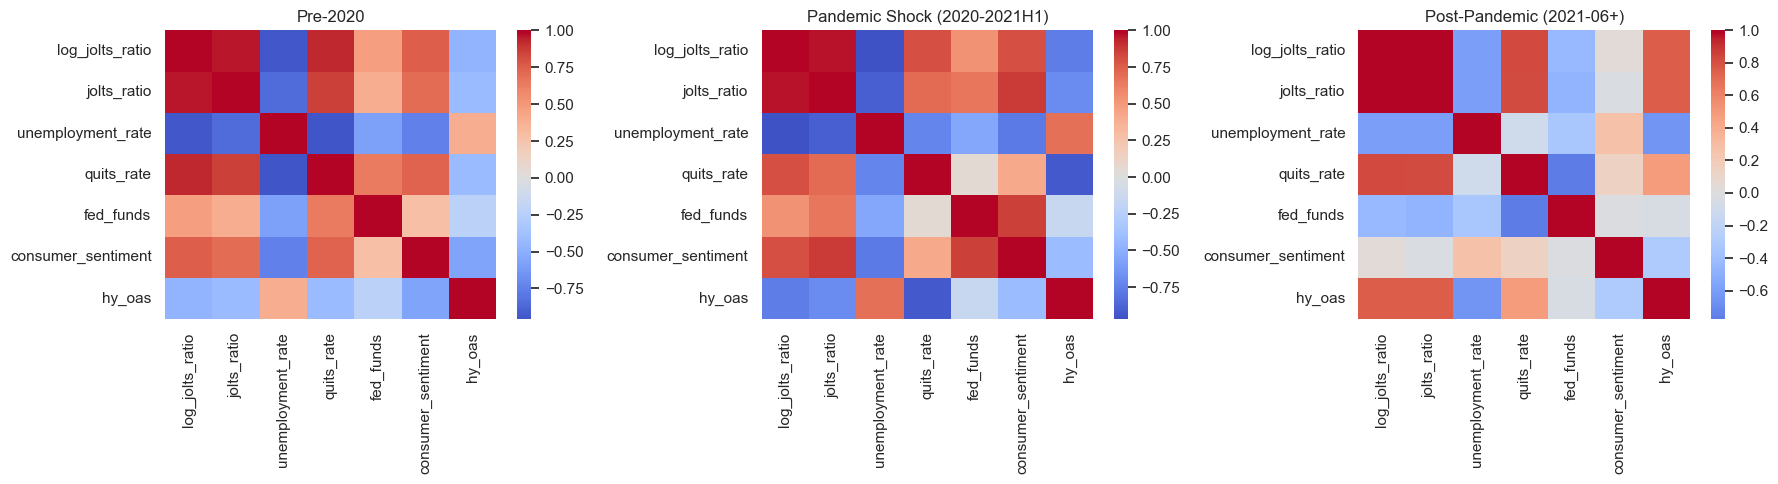

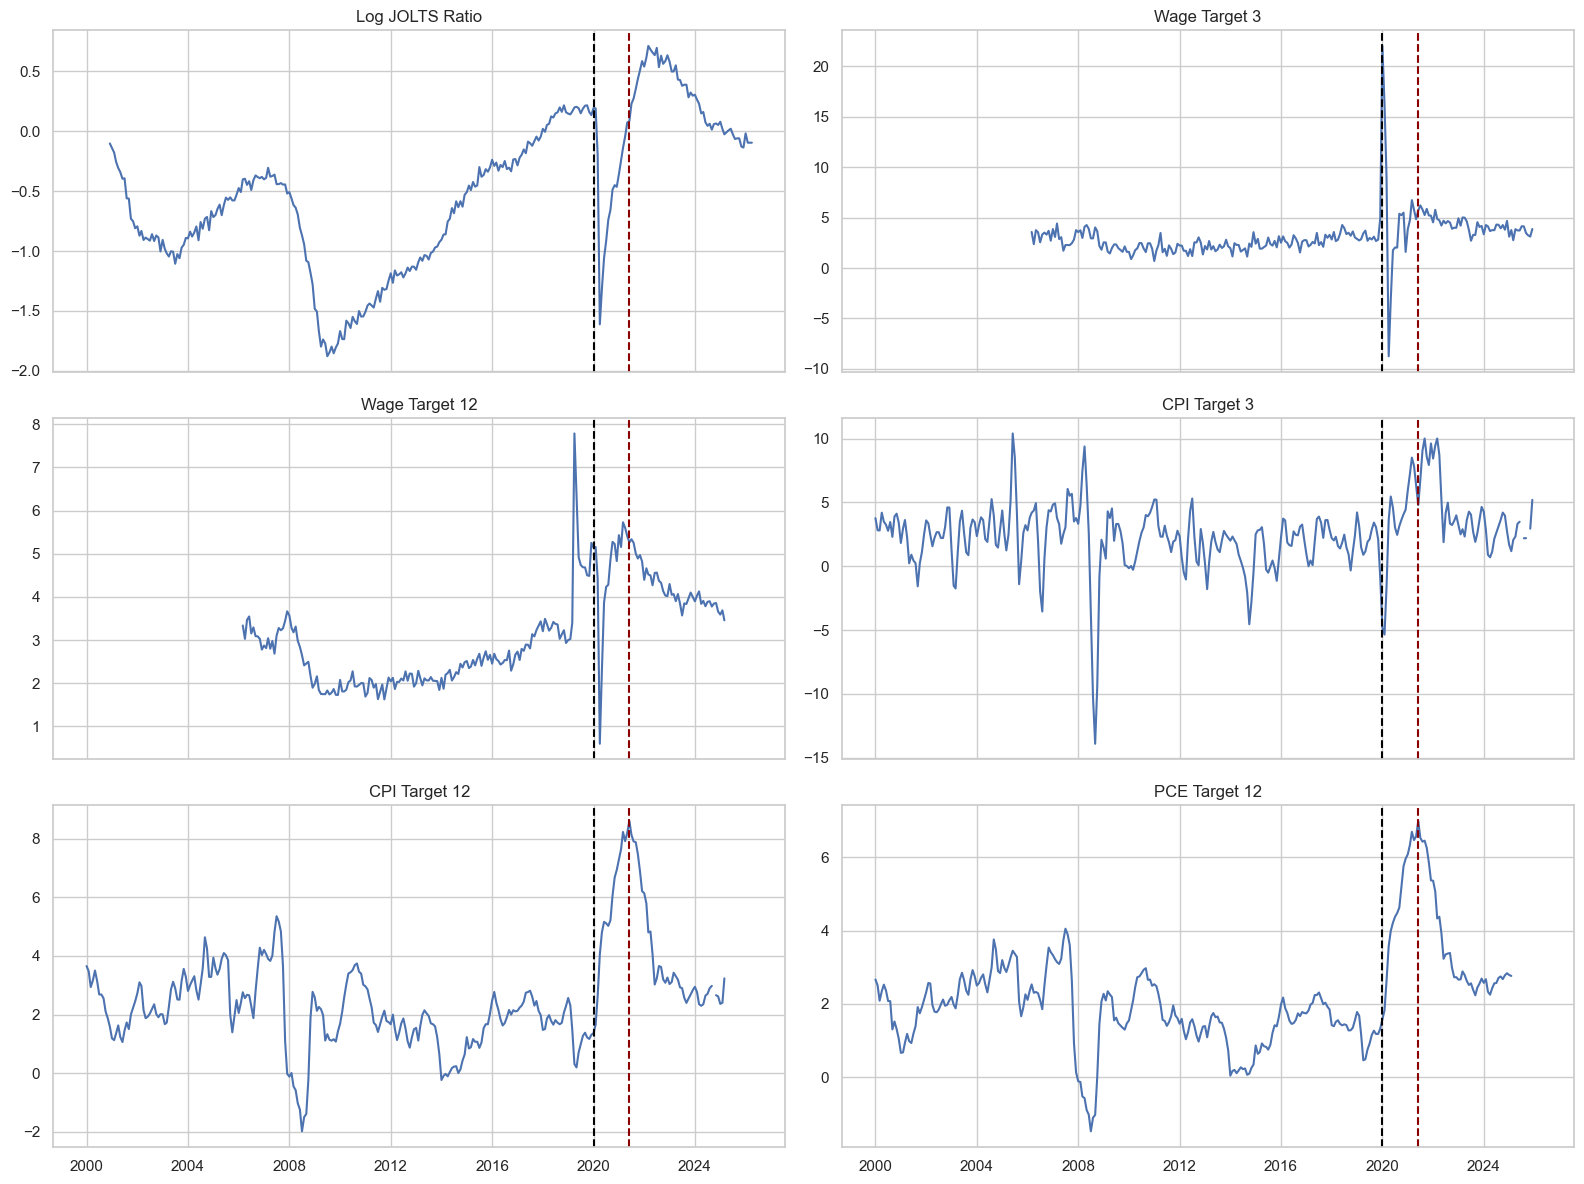

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, ["Pre-2020", "Pandemic Shock (2020-2021H1)", "Post-Pandemic (2021-06+)"]):
    use = final_data.loc[final_data["regime"] == label, heat_cols].dropna().copy()
    if len(use) > 1:
        sns.heatmap(use.corr(), cmap="coolwarm", center=0, annot=False, ax=ax)
    ax.set_title(label)

plt.tight_layout()
plt.savefig(FIG_ROOT / "04_group_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

plot_cols = [
    ("log_jolts_ratio", "Log JOLTS Ratio"),
    ("wage_target_3", "Wage Target 3"),
    ("wage_target_12", "Wage Target 12"),
    ("cpi_target_3", "CPI Target 3"),
    ("cpi_target_12", "CPI Target 12"),
    ("pce_target_12", "PCE Target 12"),
]

for ax, item in zip(axes.flatten(), plot_cols):
    col, title = item
    if col in final_data.columns:
        ax.plot(final_data["date"], final_data[col], linewidth=1.5)
        ax.axvline(shock_start, color="black", linestyle="--")
        ax.axvline(post_start, color="darkred", linestyle="--")
        ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_ROOT / "04_feature_target_view.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
feature_check = pd.DataFrame(
    {
        "feature": final_data.columns,
        "is_target": [col in target_cols for col in final_data.columns],
        "is_default_feature": [col in main_feature_cols for col in final_data.columns],
        "is_interaction_only": [col in interaction_cols for col in final_data.columns],
    }
)

feature_check.to_csv(REPORT_ROOT / "04_final_feature_list.csv", index=False)
feature_check.head(30)

,feature,is_target,is_default_feature,is_interaction_only
0,consumer_sentiment,False,True,False
1,consumer_sentiment_chg_1,False,True,False
2,consumer_sentiment_chg_3,False,True,False
3,consumer_sentiment_lag_1,False,True,False
4,consumer_sentiment_lag_3,False,True,False
5,cpi_12_post,False,False,False
6,cpi_12_shock,False,False,False
7,cpi_12_train,False,False,False
8,cpi_12_valid,False,False,False
9,cpi_3_post,False,False,False


In [44]:
model_check_cols = [
    "date",
    "regime",
    "split_role",
    "log_jolts_ratio",
    "jolts_ratio",
    "unemployment_rate",
    "quits_rate",
    "fed_funds",
    "hy_oas",
    "consumer_sentiment",
    "wage_target_3",
    "wage_target_6",
    "wage_target_12",
    "cpi_target_3",
    "cpi_target_6",
    "cpi_target_12",
    "pce_target_3",
    "pce_target_6",
    "pce_target_12",
]

model_check_cols = [col for col in model_check_cols if col in final_data.columns]
final_data[model_check_cols].head(20)

,date,regime,split_role,log_jolts_ratio,jolts_ratio,unemployment_rate,quits_rate,fed_funds,hy_oas,consumer_sentiment,wage_target_3,wage_target_6,wage_target_12,cpi_target_3,cpi_target_6,cpi_target_12,pce_target_3,pce_target_6,pce_target_12
0,2000-01-01,Pre-2020,pre_train,NaN,NaN,4.0000,NaN,5.4500,4.7843,112.0000,NaN,NaN,NaN,3.7625,3.9767,3.6536,2.6393,2.6631,2.6656
1,2000-02-01,Pre-2020,pre_train,NaN,NaN,4.1000,NaN,5.7300,4.9024,111.3000,NaN,NaN,NaN,2.8136,3.1515,3.4686,1.7124,2.0201,2.5055
2,2000-03-01,Pre-2020,pre_train,NaN,NaN,4.0000,NaN,5.8500,5.3687,107.1000,NaN,NaN,NaN,2.7972,3.0180,2.9388,1.3527,2.0223,2.0868
3,2000-04-01,Pre-2020,pre_train,NaN,NaN,3.8000,NaN,6.0200,5.8465,109.2000,NaN,NaN,NaN,4.1910,3.4804,3.1676,2.6869,2.4602,2.3455
4,2000-05-01,Pre-2020,pre_train,NaN,NaN,4.0000,NaN,6.2700,5.8978,110.7000,NaN,NaN,NaN,3.4894,3.4743,3.5011,2.3277,2.5737,2.5255
5,2000-06-01,Pre-2020,pre_train,NaN,NaN,4.0000,NaN,6.5300,6.1359,106.4000,NaN,NaN,NaN,3.2389,2.7682,3.1440,2.6918,2.2033,2.3636
6,2000-07-01,Pre-2020,pre_train,NaN,NaN,4.0000,NaN,6.5400,6.1233,108.3000,NaN,NaN,NaN,2.7698,3.3305,2.6851,2.2334,2.6681,2.0800
7,2000-08-01,Pre-2020,pre_train,NaN,NaN,4.1000,NaN,6.5000,6.3613,107.3000,NaN,NaN,NaN,3.4592,3.7856,2.6851,2.8196,2.9910,2.0748
8,2000-09-01,Pre-2020,pre_train,NaN,NaN,3.9000,NaN,6.5200,6.4536,106.8000,NaN,NaN,NaN,2.2975,2.8596,2.5591,1.7148,2.1513,1.3045
9,2000-10-01,Pre-2020,pre_train,NaN,NaN,3.9000,NaN,6.5100,7.2923,105.8000,NaN,NaN,NaN,3.8913,2.8547,2.1053,3.1028,2.2309,1.5203


## Conclusion and Next Steps